# Langgrapgh Agent with tools

In [1]:
import os 
from dotenv import load_dotenv 
load_dotenv() 
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
Weather_API_Key = os.getenv("OPENWEATHER_API_KEY")

In [14]:
from langchain.chat_models import init_chat_model

gemma = init_chat_model(model="gemma4:latest",model_provider="ollama")
deepseek = init_chat_model(model="deepseek-r1",model_provider="ollama")
#llm = init_chat_model(model="qwen/qwen3-32b", model_provider="Groq")
llm_primary = init_chat_model(model="llama-3.3-70b-versatile", model_provider="Groq")
llm_fallback_1 = init_chat_model(model="gpt-5.4-nano", model_provider="OpenAI")

In [17]:
deepseek.invoke("Hello!")

AIMessage(content='\nHello! 😊 How can I help you today?', additional_kwargs={}, response_metadata={'model': 'deepseek-r1', 'created_at': '2026-07-26T23:10:22.070572Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13105560666, 'load_duration': 8703847333, 'prompt_eval_count': 5, 'prompt_eval_duration': 99135000, 'eval_count': 221, 'eval_duration': 4294225000, 'logprobs': None, 'model_name': 'deepseek-r1', 'model_provider': 'ollama'}, id='lc_run--019fa0b1-6842-7733-8748-99595922c6ec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 221, 'total_tokens': 226})

In [19]:
gemma.invoke("hi")

AIMessage(content='Hi! How can I help you today? 😊', additional_kwargs={}, response_metadata={'model': 'gemma4:latest', 'created_at': '2026-07-26T23:10:31.063773Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3361299583, 'load_duration': 221612417, 'prompt_eval_count': 17, 'prompt_eval_duration': 44624000, 'eval_count': 217, 'eval_duration': 3094139000, 'logprobs': None, 'model_name': 'gemma4:latest', 'model_provider': 'ollama'}, id='lc_run--019fa0b1-b174-7363-aab7-6754886e71db-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 217, 'total_tokens': 234})

## Create tools 

### weather tool 

In [4]:
## Create a weather tool 
from langchain.tools import tool
import requests

@tool
def getWeather(location:str)->str:
    """Return the weather information based on the given location and or zipcode"""
    url = "https://api.openweathermap.org/data/2.5/weather?"

    params={
        "q":location,
        "appid":Weather_API_Key,
        "units":"imperial"
    }

    try:
        response = requests.get(url,params=params,timeout=10)
        return response.json()
    except:
        return f"The requested weather information is not available"

### web_serch tool 

In [5]:
# Search tool using Tavily 
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=3, 
    topic="general",
    search_depth="basic"
)

## create tools pool

In [6]:
tools = [getWeather, web_search]
tool_names = {tool.name: tool for tool in tools}
tool_names

{'getWeather': StructuredTool(name='getWeather', description='Return the weather information based on the given location and or zipcode', args_schema=<class 'langchain_core.utils.pydantic.getWeather'>, func=<function getWeather at 0x11b5565c0>),
 'tavily_search': TavilySearch(search_depth='basic', max_results=3, topic='general', api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))}

## Create llm_node

In [7]:
# Create our llm node
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain.messages import SystemMessage, HumanMessage, AIMessage

llm_with_tools = gemma.bind_tools(tools)
#llm_with_tools = llm_primary.bind_tools(tools)
#llm_with_tools = llm_fallback_1.bind_tools(tools)

def llm_node(state:MessagesState)->str:
    response = llm_with_tools.invoke([
        SystemMessage(content="You are a helpful assistant. Use getWeather tool for weather related query. Use web_search tool for news, current affairs, stocks and anything new. Otherwise, just provide the answeer of your own.")
    ] + state["messages"]
    ) 
    
    return {"messages": [response]}

# Create an alternative tool node

In [8]:
from langgraph.prebuilt import ToolNode, tools_condition
tool_node = ToolNode(tools)

## Add short-term memory

In [9]:
from langgraph.checkpoint.memory import InMemorySaver 
memory = InMemorySaver()

# Now lets create the graph agent 

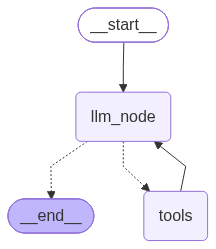

In [10]:
# from langgraph.graph import StateGraph, START, END

graph = StateGraph(MessagesState)

graph.add_node("llm_node",llm_node)
graph.add_node("tools",tool_node)

graph.add_edge(START,"llm_node")
graph.add_conditional_edges(
    "llm_node", tools_condition,["tools",END]
)

graph.add_edge("tools","llm_node")

graph = graph.compile(checkpointer=memory)

graph

# Configuration for thread id 

In [11]:
configure = {"configurable":{"thread_id":1}}

# import model ratelimit exception

In [12]:
from openai import RateLimitError as OpenAIRateLimitError
from groq import RateLimitError as GroqRateLimitError

## Test the graph agent

In [13]:
try: 
    response = graph.invoke({
        "messages":[
            HumanMessage(content="What is the top political news today in USA?")
        ]
    },config=configure)


    for m in response["messages"]:
        m.pretty_print()
except (OpenAIRateLimitError, GroqRateLimitError) as rateError:
    print("LLM Rate limit is reached, Error:",rateError)
except Exception as e:
    print("Model failed to answer your query. Error:",e)

================================ Human Message =================================

What is the top political news today in USA?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (88b3c872-f8a4-4e56-99c0-b5b9279af909)
 Call ID: 88b3c872-f8a4-4e56-99c0-b5b9279af909
  Args:
    query: top political news USA today
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "top political news USA today", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.politico.com/politics", "title": "Latest and breaking political news today - POLITICO", "content": "## STATE POLITICS & POLICY. *   Image 1: Josh Shapiro and Hakeem Jeffries attend a campaign event. The minority leader kicked off the final sprint of the midterms from a union hall in a Pennsylvania battleground district. *   Image 4: Troy Jackson gestures a